# 🏀 Análisis de Sesión — Basket Tracker micro:bit
**Proyecto:** Sistema de medición de lanzamientos con BBC micro:bit V1.5 + BLE  
**Análisis:** Potencia, ejes X/Y/Z, consistencia, rendimiento y firma de movimiento

In [1]:
%pip install pandas numpy matplotlib seaborn scipy -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ─── 0. Imports ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo global
plt.rcParams.update({
    'figure.facecolor': '#0F0F0F',
    'axes.facecolor':   '#1A1A1A',
    'axes.edgecolor':   '#333333',
    'axes.labelcolor':  '#CCCCCC',
    'xtick.color':      '#888888',
    'ytick.color':      '#888888',
    'text.color':       '#CCCCCC',
    'grid.color':       '#2A2A2A',
    'grid.linestyle':   '--',
    'legend.facecolor': '#1A1A1A',
    'legend.edgecolor': '#333333',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

CESTA_COLOR = '#00D4AA'
FALLO_COLOR = '#FF4C6A'
X_COLOR     = '#4C9BFF'
Y_COLOR     = '#FFB84C'
Z_COLOR     = '#C84CFF'
POTENCIA_COLOR = '#FFFFFF'

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [3]:
# ─── 1. Carga y preparación de datos ─────────────────────────────────────────
df = pd.read_csv(r'D:\MicroBit\data\db\BD_tiros.csv')

# Parsear timestamp y calcular tiempo relativo por tiro en milisegundos
df['ts_parsed'] = pd.to_datetime(df['timestamp'], format='%H:%M:%S.%f')
df['ts_ms']     = (df['ts_parsed'] - df['ts_parsed'].iloc[0]).dt.total_seconds() * 1000

# Tiempo relativo dentro de cada tiro (ms desde primera muestra del tiro)
df['ts_tiro_ms'] = df.groupby('tiro')['ts_ms'].transform(lambda x: x - x.iloc[0])

# Etiqueta de resultado
df['resultado'] = df['cesta'].map({1: 'CESTA', 0: 'FALLO'})

SESSION_ID = df['session'].iloc[0]
TIROS      = sorted(df['tiro'].unique())

print(f'Sesiones incluidas: {df["session"].nunique()}')
print(f'Total tiros:    {len(TIROS)}')
print(f'Total muestras: {len(df)}')
print(f'Cestas:         {df.groupby("tiro")["cesta"].first().sum()}')
print(f'Fallos:         {(df.groupby("tiro")["cesta"].first()==0).sum()}')
print(f'Efectividad:    {df.groupby("tiro")["cesta"].first().mean()*100:.1f}%')
df.head(8)

Sesiones incluidas: 19
Total tiros:    411
Total muestras: 3617
Cestas:         139
Fallos:         272
Efectividad:    33.8%


,timestamp,session,tiro,x,y,z,potencia,cesta,ts_parsed,ts_ms,ts_tiro_ms,resultado
0,18:06:51.459,20260615_1F873475,1,-84,744,-688,1016.83,1,1900-01-01 18:06:51.459,0.0,0.0,CESTA
1,18:06:52.057,20260615_1F873475,1,-68,752,-684,1018.81,1,1900-01-01 18:06:52.057,598.0,598.0,CESTA
2,18:06:52.688,20260615_1F873475,1,-40,732,-708,1019.16,1,1900-01-01 18:06:52.688,1229.0,1229.0,CESTA
3,18:06:53.288,20260615_1F873475,1,-48,732,-696,1011.21,1,1900-01-01 18:06:53.288,1829.0,1829.0,CESTA
4,18:06:53.889,20260615_1F873475,1,-52,736,-716,1028.13,1,1900-01-01 18:06:53.889,2430.0,2430.0,CESTA
5,18:06:54.487,20260615_1F873475,1,-48,732,-700,1013.97,1,1900-01-01 18:06:54.487,3028.0,3028.0,CESTA
6,18:06:55.088,20260615_1F873475,1,-44,736,-700,1016.68,1,1900-01-01 18:06:55.088,3629.0,3629.0,CESTA
7,18:06:55.687,20260615_1F873475,1,-48,736,-696,1014.11,1,1900-01-01 18:06:55.687,4228.0,4228.0,CESTA


In [4]:
# ─── 2. Métricas por tiro ─────────────────────────────────────────────────────
metricas = df.groupby('tiro').agg(
    resultado      = ('resultado', 'first'),
    cesta          = ('cesta', 'first'),
    muestras       = ('potencia', 'count'),
    duracion_ms    = ('ts_tiro_ms', 'max'),
    duracion_s     = ('ts_tiro_ms', lambda s: round(s.max()/1000, 2)),
    pot_max        = ('potencia', 'max'),
    pot_avg        = ('potencia', 'mean'),
    pot_min        = ('potencia', 'min'),
    pot_std        = ('potencia', 'std'),
    x_abs_max      = ('x', lambda s: s.abs().max()),
    y_abs_max      = ('y', lambda s: s.abs().max()),
    z_abs_max      = ('z', lambda s: s.abs().max()),
).round(2).reset_index()

# Índice de consistencia: inverso de coeficiente de variación (0–1, mayor = más consistente)
metricas['consistencia'] = (1 - (metricas['pot_std'] / metricas['pot_avg'])).clip(0, 1).round(3)

print('Métricas por tiro:')
metricas[['tiro','resultado','muestras','duracion_ms','duracion_s', 
           'pot_max','pot_avg','pot_std','consistencia']]

Métricas por tiro:


,tiro,resultado,muestras,duracion_ms,duracion_s,pot_max,pot_avg,pot_std,consistencia
0,1,CESTA,17,9659.0,9.66,1028.13,1016.35,4.21,0.996
1,2,FALLO,20,11521.0,11.52,1033.80,1016.59,7.42,0.993
2,3,CESTA,19,10890.0,10.89,1039.61,1014.20,23.36,0.977
3,4,FALLO,9,4949.0,4.95,2589.76,1310.68,708.56,0.459
4,5,FALLO,8,4230.0,4.23,2436.98,1222.14,733.94,0.399
...,...,...,...,...,...,...,...,...,...
406,407,FALLO,7,3257.0,3.26,1808.82,1180.08,370.01,0.686
407,408,CESTA,6,2746.0,2.75,2587.08,1430.16,686.56,0.520
408,409,FALLO,6,2715.0,2.72,2967.44,1471.74,749.38,0.491
409,410,CESTA,6,2700.0,2.70,3273.47,1543.83,863.03,0.441


In [5]:
# ─── 3. KPIs de la sesión ────────────────────────────────────────────────────
cestas_df  = metricas[metricas['cesta'] == 1]
fallos_df  = metricas[metricas['cesta'] == 0]

kpis = {
    '% efectividad':              f"{metricas['cesta'].mean()*100:.1f}%",
    'Tiros totales':               len(metricas),
    'Cestas':                      len(cestas_df),
    'Fallos':                      len(fallos_df),
    'Potencia máx. global (mg)':   f"{metricas['pot_max'].max():.0f}",
    'Potencia prom. cestas (mg)':  f"{cestas_df['pot_avg'].mean():.0f}",
    'Potencia prom. fallos  (mg)': f"{fallos_df['pot_avg'].mean():.0f}",
    'Rango óptimo potencia (mg)':  f"{cestas_df['pot_max'].min():.0f} – {cestas_df['pot_max'].max():.0f}",
    'Duración prom. gesto (ms)':   f"{metricas['duracion_ms'].mean():.0f}",
    'Consistencia prom. cestas':   f"{cestas_df['consistencia'].mean():.3f}",
    'Consistencia prom. fallos':   f"{fallos_df['consistencia'].mean():.3f}",
}

print('\n📊 KPIs de la sesión\n' + '─'*40)
for k, v in kpis.items():
    print(f'  {k:<35} {v}')


📊 KPIs de la sesión
────────────────────────────────────────
  % efectividad                       33.8%
  Tiros totales                       411
  Cestas                              139
  Fallos                              272
  Potencia máx. global (mg)           3413
  Potencia prom. cestas (mg)          1316
  Potencia prom. fallos  (mg)         1314
  Rango óptimo potencia (mg)          1028 – 3273
  Duración prom. gesto (ms)           4281
  Consistencia prom. cestas           0.629
  Consistencia prom. fallos           0.615


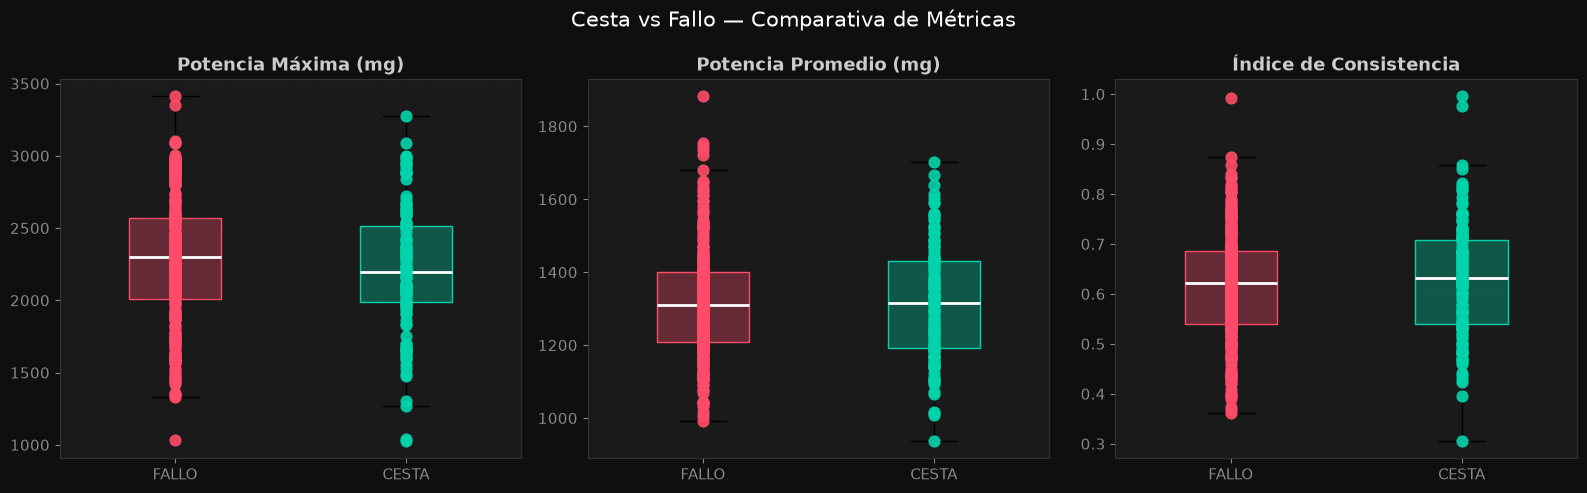

In [6]:
# ─── 5. Comparativa cesta vs fallo ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='#0F0F0F')

metricas_plot = [('pot_max', 'Potencia Máxima (mg)'),
                 ('pot_avg', 'Potencia Promedio (mg)'),
                 ('consistencia', 'Índice de Consistencia')]

for ax, (col, titulo) in zip(axes, metricas_plot):
    data_c = metricas[metricas['cesta'] == 1][col]
    data_f = metricas[metricas['cesta'] == 0][col]

    bp = ax.boxplot([data_f, data_c],
                    patch_artist=True,
                    tick_labels=['FALLO', 'CESTA'],
                    widths=0.4,
                    medianprops=dict(color='white', lw=2))

    bp['boxes'][0].set_facecolor(FALLO_COLOR + '55')
    bp['boxes'][0].set_edgecolor(FALLO_COLOR)
    bp['boxes'][1].set_facecolor(CESTA_COLOR + '55')
    bp['boxes'][1].set_edgecolor(CESTA_COLOR)

    # Scatter de puntos individuales
    for j, (datos, color) in enumerate([(data_f, FALLO_COLOR), (data_c, CESTA_COLOR)]):
        ax.scatter([j + 1] * len(datos), datos,
                   color=color, zorder=5, s=60, alpha=0.9)

    ax.set_title(titulo)
    ax.grid(True, alpha=0.3)

fig.suptitle('Cesta vs Fallo — Comparativa de Métricas', fontsize=15, color='white')
plt.tight_layout()
plt.savefig('comparativa_cesta_fallo.png', dpi=150, bbox_inches='tight', facecolor='#0F0F0F')
plt.show()

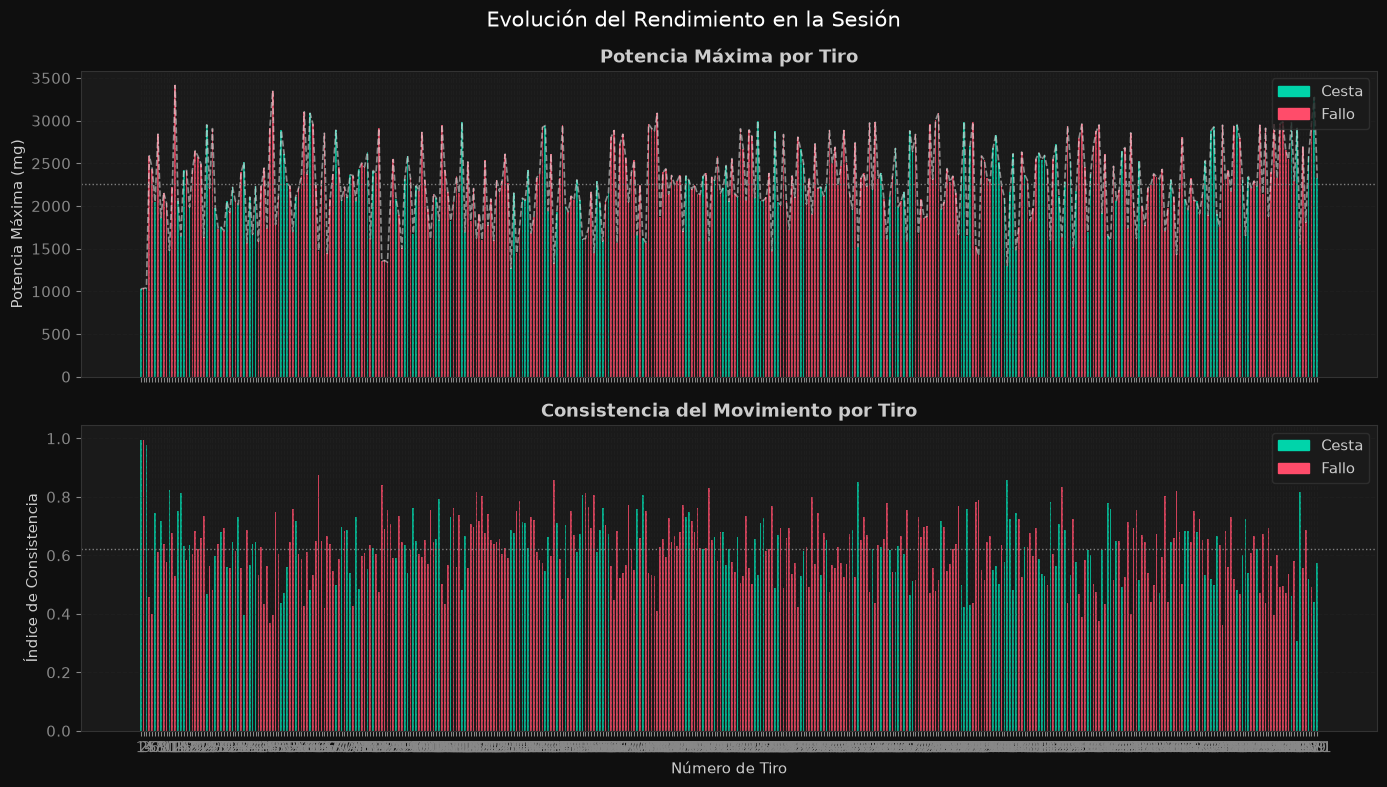

In [7]:
# ─── 6. Evolución de rendimiento en la sesión ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), facecolor='#0F0F0F', sharex=True)

x = metricas['tiro']
colores = [CESTA_COLOR if c == 1 else FALLO_COLOR for c in metricas['cesta']]

# Potencia máxima con color por resultado
ax1.bar(x, metricas['pot_max'], color=colores, alpha=0.8, width=0.6)
ax1.plot(x, metricas['pot_max'], color='white', lw=1.2, ls='--', alpha=0.5)
ax1.axhline(metricas['pot_max'].mean(), color='gray', lw=1, ls=':', label='Prom. sesión')
ax1.set_ylabel('Potencia Máxima (mg)')
ax1.set_title('Potencia Máxima por Tiro')
ax1.legend()
ax1.grid(True, alpha=0.3)

cesta_patch = mpatches.Patch(color=CESTA_COLOR, label='Cesta')
fallo_patch = mpatches.Patch(color=FALLO_COLOR, label='Fallo')
ax1.legend(handles=[cesta_patch, fallo_patch], loc='upper right')

# Consistencia por tiro
ax2.bar(x, metricas['consistencia'], color=colores, alpha=0.8, width=0.6)
ax2.axhline(metricas['consistencia'].mean(), color='gray', lw=1, ls=':', label='Prom. sesión')
ax2.set_ylabel('Índice de Consistencia')
ax2.set_xlabel('Número de Tiro')
ax2.set_title('Consistencia del Movimiento por Tiro')
ax2.set_xticks(x)
ax2.legend(handles=[cesta_patch, fallo_patch], loc='upper right')
ax2.grid(True, alpha=0.3)

fig.suptitle('Evolución del Rendimiento en la Sesión', fontsize=15, color='white')
plt.tight_layout()
plt.savefig('evolucion_sesion.png', dpi=150, bbox_inches='tight', facecolor='#0F0F0F')
plt.show()

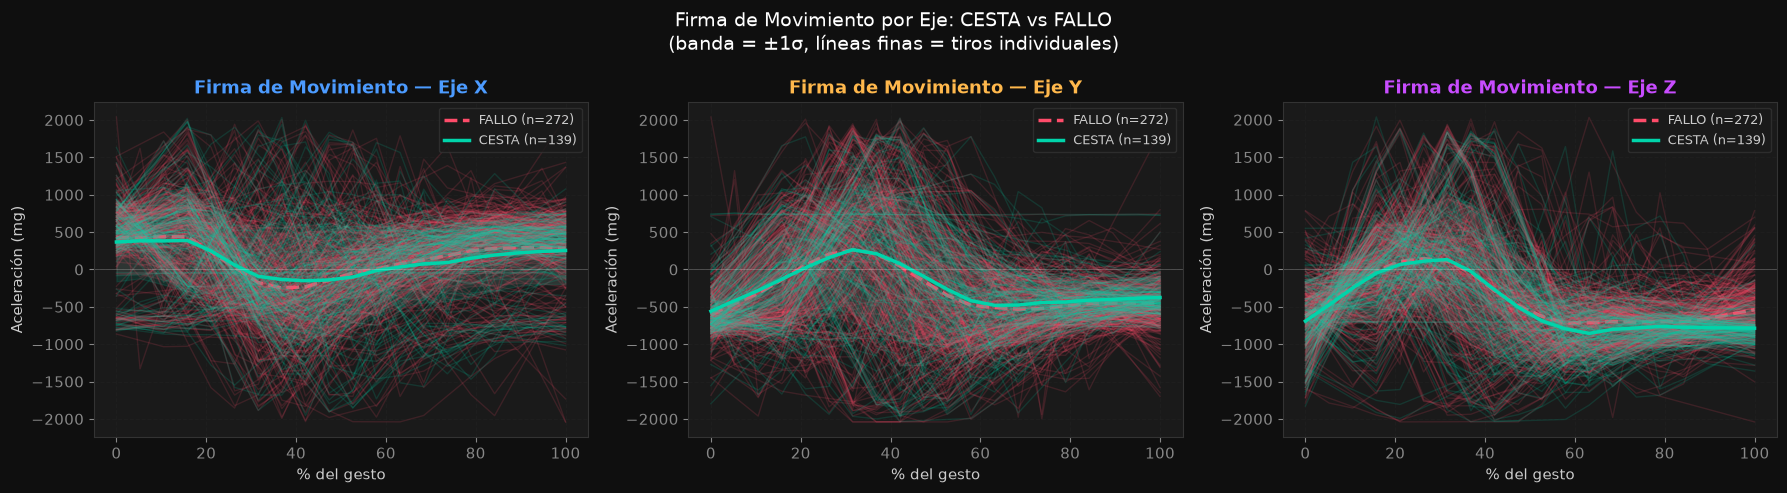

In [8]:
# ─── 8. Firma de movimiento: cestas vs fallos por eje ────────────────────────
# Interpolar cada tiro a 10 puntos normalizados en el tiempo para poder comparar
N_PUNTOS = 20

def interpolar_tiro(sub, col):
    t_orig = sub['ts_tiro_ms'].values
    v_orig = sub[col].values
    t_norm = np.linspace(t_orig.min(), t_orig.max(), N_PUNTOS)
    return np.interp(t_norm, t_orig, v_orig)

firmas = {eje: {'CESTA': [], 'FALLO': []} for eje in ['x', 'y', 'z']}

for tiro_id in TIROS:
    sub    = df[df['tiro'] == tiro_id]
    grupo  = 'CESTA' if sub['cesta'].iloc[0] == 1 else 'FALLO'
    for eje in ['x', 'y', 'z']:
        if len(sub) >= 2:
            firmas[eje][grupo].append(interpolar_tiro(sub, eje))

t_norm = np.linspace(0, 100, N_PUNTOS)  # tiempo normalizado 0–100%

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0F0F0F')
eje_colores = {'x': X_COLOR, 'y': Y_COLOR, 'z': Z_COLOR}
eje_labels  = {'x': 'Eje X', 'y': 'Eje Y', 'z': 'Eje Z'}

for ax, eje in zip(axes, ['x', 'y', 'z']):
    eje_color = eje_colores[eje]

    for grupo, color, ls in [('FALLO', FALLO_COLOR, '--'), ('CESTA', CESTA_COLOR, '-')]:
        datos = np.array(firmas[eje][grupo])
        if len(datos) == 0:
            continue

        media = datos.mean(axis=0)
        std   = datos.std(axis=0)

        # Tiros individuales (transparentes)
        for fila in datos:
            ax.plot(t_norm, fila, color=color, alpha=0.15, lw=1)

        # Media + banda de desviación estándar
        ax.plot(t_norm, media, color=color, lw=2.5, ls=ls, label=f'{grupo} (n={len(datos)})')
        ax.fill_between(t_norm, media - std, media + std, color=color, alpha=0.12)

    ax.axhline(0, color='white', lw=0.5, alpha=0.3)
    ax.set_title(f'Firma de Movimiento — {eje_labels[eje]}', color=eje_color)
    ax.set_xlabel('% del gesto')
    ax.set_ylabel('Aceleración (mg)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

fig.suptitle('Firma de Movimiento por Eje: CESTA vs FALLO\n(banda = ±1σ, líneas finas = tiros individuales)',
             fontsize=14, color='white')
plt.tight_layout()
plt.savefig('firma_movimiento_ejes.png', dpi=150, bbox_inches='tight', facecolor='#0F0F0F')
plt.show()

In [9]:
# ─── 9. Estadísticas descriptivas por eje y resultado ────────────────────────
stats_df = df.groupby('resultado')[['x', 'y', 'z', 'potencia']].agg(
    ['mean', 'std', 'min', 'max']
).round(1)

print('\n📐 Estadísticas descriptivas por eje y resultado:\n')
print(stats_df.to_string())

# Test estadístico: ¿la potencia media es significativamente diferente entre cestas y fallos?
pot_cestas = df[df['cesta'] == 1]['potencia']
pot_fallos = df[df['cesta'] == 0]['potencia']
t_stat, p_val = stats.ttest_ind(pot_cestas, pot_fallos)

print(f'\n📊 Test t de potencia (cesta vs fallo):')
print(f'   t = {t_stat:.3f}, p = {p_val:.4f}')
if p_val < 0.05:
    print('   → Diferencia estadísticamente significativa (p < 0.05)')
else:
    print('   → Sin diferencia significativa aún (se necesitan más tiros)')


📐 Estadísticas descriptivas por eje y resultado:

               x                         y                         z                    potencia                      
            mean    std   min   max   mean    std   min   max   mean    std   min   max     mean    std    min     max
resultado                                                                                                             
CESTA      146.9  704.6 -2040  2040 -294.7  733.3 -2040  2040 -476.8  725.7 -2040  2040   1286.9  489.1  102.1  3273.5
FALLO      197.3  698.1 -2040  2040 -369.8  765.3 -2040  2040 -389.4  707.0 -2040  2040   1285.0  498.4   66.1  3413.2

📊 Test t de potencia (cesta vs fallo):
   t = 0.109, p = 0.9135
   → Sin diferencia significativa aún (se necesitan más tiros)


## 9b. Gráficos analíticos por eje — biomecánica del lanzamiento
Un gráfico por eje (X, Y, Z), pensado para explicar a jugador/entrenador qué diferencia una CESTA de un FALLO en cada dirección de movimiento.

In [10]:
from pathlib import Path
# ─── 9b.0 Setup — gráficos analíticos por eje ─────────────────────────────────
RESULTS_FIG = Path('../results/figures')
RESULTS_TAB = Path('../results/tables')
RESULTS_FIG.mkdir(parents=True, exist_ok=True)
RESULTS_TAB.mkdir(parents=True, exist_ok=True)

GOLD = '#FFD700'


def eje_stats(col):
    c = df[df['cesta'] == 1][col]
    f = df[df['cesta'] == 0][col]
    return c, f


def plot_axis_header(ax, title, xlabel, ylabel='Densidad'):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)


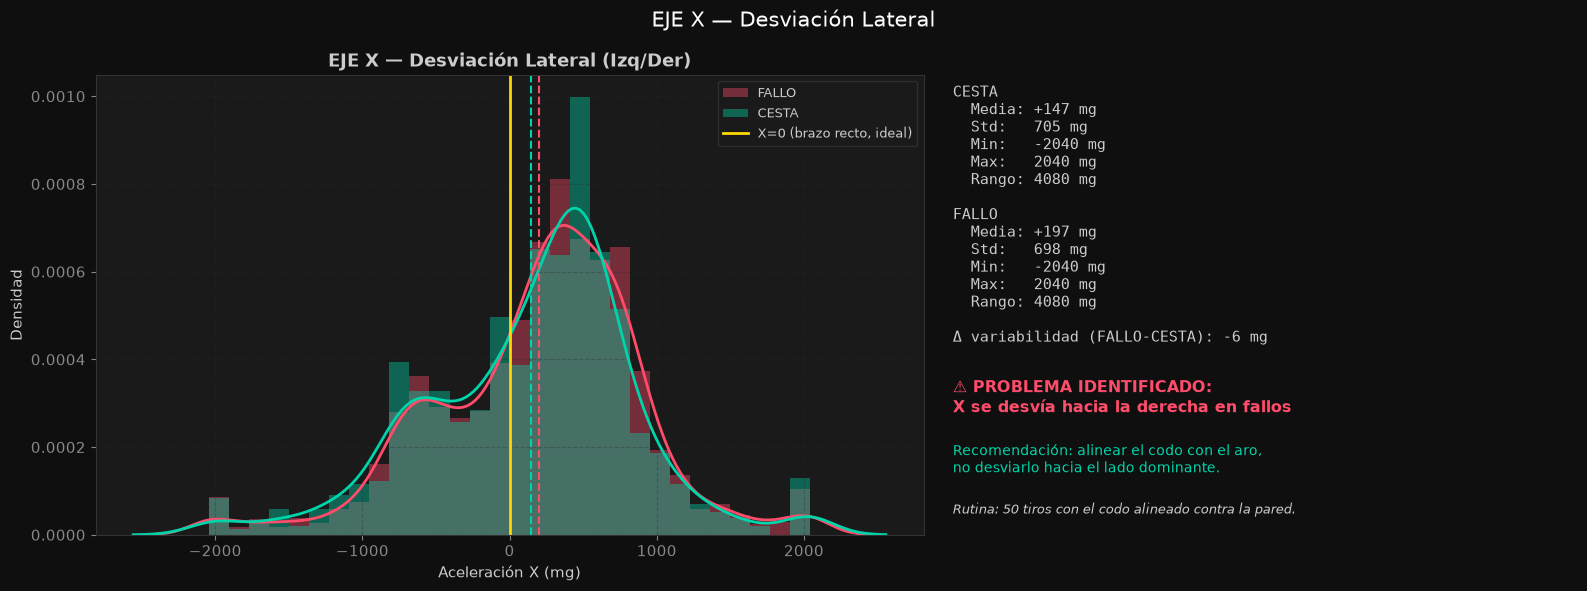

In [11]:
# ─── 9b.1 EJE X — Desviación lateral (Izq/Der) ────────────────────────────────
x_cesta, x_fallo = eje_stats('x')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0F0F0F',
                                gridspec_kw={'width_ratios': [1.3, 1]})

# Subplot 1: histograma + KDE comparativo
ax1.hist(x_fallo, bins=30, density=True, color=FALLO_COLOR, alpha=0.4, label='FALLO')
ax1.hist(x_cesta, bins=30, density=True, color=CESTA_COLOR, alpha=0.4, label='CESTA')
sns.kdeplot(x_fallo, ax=ax1, color=FALLO_COLOR, lw=2)
sns.kdeplot(x_cesta, ax=ax1, color=CESTA_COLOR, lw=2)
ax1.axvline(0, color=GOLD, lw=2, label='X=0 (brazo recto, ideal)')
ax1.axvline(x_cesta.mean(), color=CESTA_COLOR, lw=1.5, ls='--')
ax1.axvline(x_fallo.mean(), color=FALLO_COLOR, lw=1.5, ls='--')
ax1.legend(fontsize=9)
plot_axis_header(ax1, 'EJE X — Desviación Lateral (Izq/Der)', 'Aceleración X (mg)')

# Subplot 2: estadísticas + insight accionable
ax2.axis('off')
diff_std = x_fallo.std() - x_cesta.std()
texto = (
    f"CESTA\n"
    f"  Media: {x_cesta.mean():+.0f} mg\n"
    f"  Std:   {x_cesta.std():.0f} mg\n"
    f"  Min:   {x_cesta.min():.0f} mg\n"
    f"  Max:   {x_cesta.max():.0f} mg\n"
    f"  Rango: {x_cesta.max() - x_cesta.min():.0f} mg\n\n"
    f"FALLO\n"
    f"  Media: {x_fallo.mean():+.0f} mg\n"
    f"  Std:   {x_fallo.std():.0f} mg\n"
    f"  Min:   {x_fallo.min():.0f} mg\n"
    f"  Max:   {x_fallo.max():.0f} mg\n"
    f"  Rango: {x_fallo.max() - x_fallo.min():.0f} mg\n\n"
    f"Δ variabilidad (FALLO-CESTA): {diff_std:+.0f} mg"
)
ax2.text(0.02, 0.98, texto, va='top', ha='left', fontsize=10.5,
         family='monospace', transform=ax2.transAxes)

problema_x = 'X se desvía hacia la izquierda en fallos' if x_fallo.mean() < x_cesta.mean() \
    else 'X se desvía hacia la derecha en fallos'
ax2.text(0.02, 0.34, f'⚠ PROBLEMA IDENTIFICADO:\n{problema_x}', fontsize=11.5,
         fontweight='bold', color=FALLO_COLOR, transform=ax2.transAxes, va='top')
ax2.text(0.02, 0.20,
         'Recomendación: alinear el codo con el aro,\nno desviarlo hacia el lado dominante.',
         fontsize=10, color=CESTA_COLOR, transform=ax2.transAxes, va='top')
ax2.text(0.02, 0.07, 'Rutina: 50 tiros con el codo alineado contra la pared.',
         fontsize=9.5, style='italic', transform=ax2.transAxes, va='top')

fig.suptitle('EJE X — Desviación Lateral', fontsize=15, color='white')
plt.tight_layout()
plt.savefig(RESULTS_FIG / 'axis_X_desviacion_lateral.png', dpi=300, bbox_inches='tight', facecolor='#0F0F0F')
plt.show()


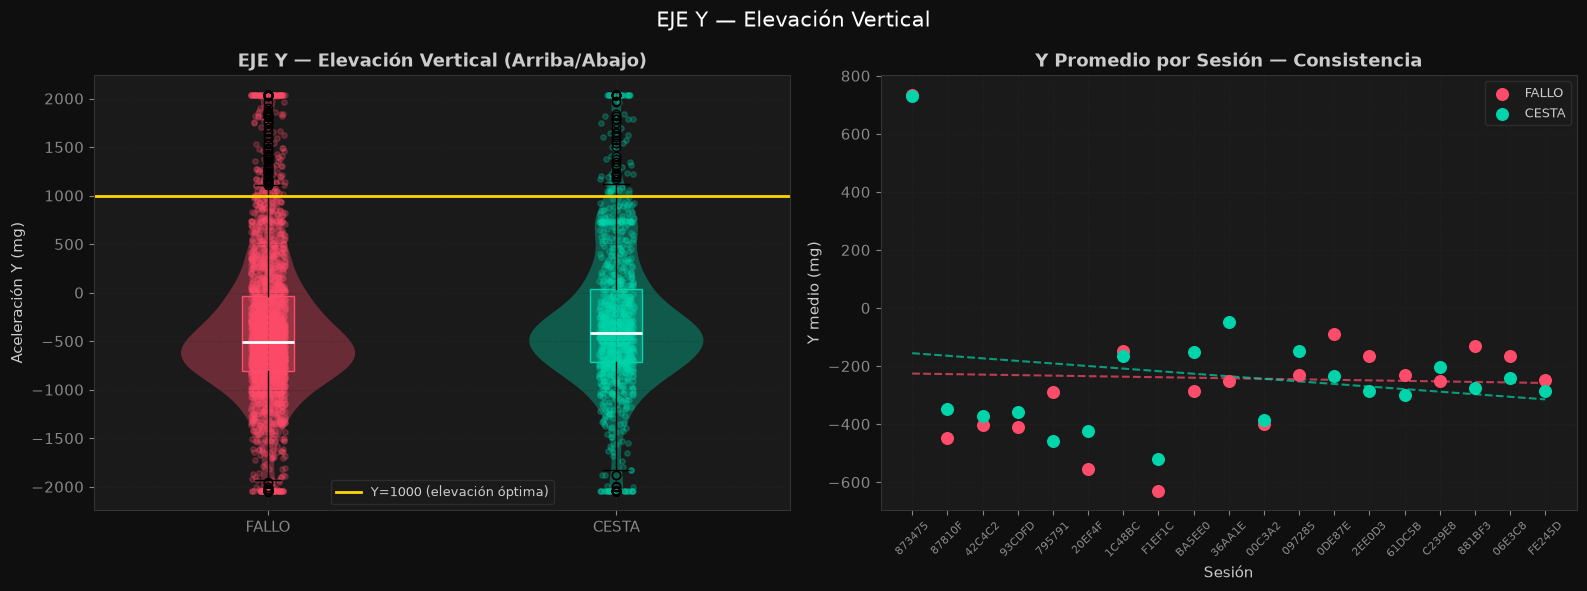

In [12]:
# ─── 9b.2 EJE Y — Elevación vertical (Arriba/Abajo) ───────────────────────────
y_cesta, y_fallo = eje_stats('y')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0F0F0F')

# Subplot 1: violin + box + puntos individuales
parts = ax1.violinplot([y_fallo, y_cesta], positions=[1, 2], showextrema=False)
for pc, color in zip(parts['bodies'], [FALLO_COLOR, CESTA_COLOR]):
    pc.set_facecolor(color)
    pc.set_alpha(0.35)

bp = ax1.boxplot([y_fallo, y_cesta], positions=[1, 2], widths=0.15,
                  patch_artist=True, tick_labels=['FALLO', 'CESTA'],
                  medianprops=dict(color='white', lw=2))
bp['boxes'][0].set_facecolor(FALLO_COLOR + '55'); bp['boxes'][0].set_edgecolor(FALLO_COLOR)
bp['boxes'][1].set_facecolor(CESTA_COLOR + '55'); bp['boxes'][1].set_edgecolor(CESTA_COLOR)

rng = np.random.default_rng(0)
for pos, datos, color in [(1, y_fallo, FALLO_COLOR), (2, y_cesta, CESTA_COLOR)]:
    jitter = rng.uniform(-0.05, 0.05, size=len(datos))
    ax1.scatter(pos + jitter, datos, color=color, alpha=0.25, s=15, zorder=1)

ax1.axhline(1000, color=GOLD, lw=2, label='Y=1000 (elevación óptima)')
ax1.legend(fontsize=9)
plot_axis_header(ax1, 'EJE Y — Elevación Vertical (Arriba/Abajo)', '', 'Aceleración Y (mg)')

# Subplot 2: evolución de Y promedio por sesión
sesion_y = df.groupby(['session', 'resultado'])['y'].mean().unstack()
sesiones_idx = np.arange(len(sesion_y))

for resultado, color in [('FALLO', FALLO_COLOR), ('CESTA', CESTA_COLOR)]:
    if resultado not in sesion_y:
        continue
    serie = sesion_y[resultado]
    validos = serie.notna()
    ax2.scatter(sesiones_idx[validos], serie[validos], color=color, s=70, label=resultado, zorder=3)
    if validos.sum() > 1:
        m, b = np.polyfit(sesiones_idx[validos], serie[validos], 1)
        ax2.plot(sesiones_idx, m * sesiones_idx + b, color=color, ls='--', alpha=0.7)

ax2.set_xticks(sesiones_idx)
ax2.set_xticklabels([str(s)[-6:] for s in sesion_y.index], rotation=45, fontsize=8)
ax2.legend(fontsize=9)
plot_axis_header(ax2, 'Y Promedio por Sesión — Consistencia', 'Sesión', 'Y medio (mg)')

fig.suptitle('EJE Y — Elevación Vertical', fontsize=15, color='white')
plt.tight_layout()
plt.savefig(RESULTS_FIG / 'axis_Y_elevacion_vertical.png', dpi=300, bbox_inches='tight', facecolor='#0F0F0F')
plt.show()


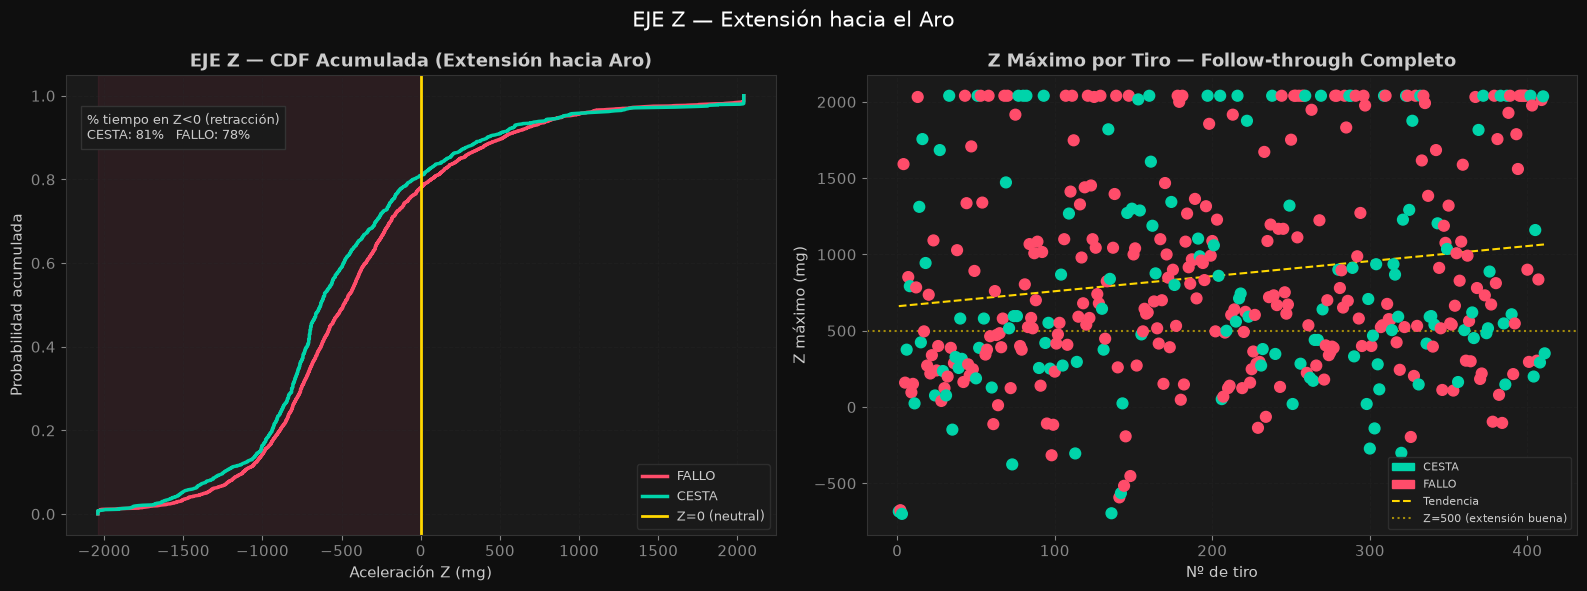

In [13]:
# ─── 9b.3 EJE Z — Extensión hacia el aro (follow-through) ─────────────────────
z_cesta, z_fallo = eje_stats('z')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0F0F0F')

# Subplot 1: CDF acumulada
for datos, color, label in [(z_fallo, FALLO_COLOR, 'FALLO'), (z_cesta, CESTA_COLOR, 'CESTA')]:
    sorted_d = np.sort(datos)
    cdf = np.arange(1, len(sorted_d) + 1) / len(sorted_d)
    ax1.plot(sorted_d, cdf, color=color, lw=2.5, label=label)

ax1.axvline(0, color=GOLD, lw=2, label='Z=0 (neutral)')
xmin = min(z_cesta.min(), z_fallo.min())
ax1.axvspan(xmin, 0, color=FALLO_COLOR, alpha=0.08)

pct_neg_cesta = (z_cesta < 0).mean() * 100
pct_neg_fallo = (z_fallo < 0).mean() * 100
ax1.text(0.03, 0.92,
         f'% tiempo en Z<0 (retracción)\nCESTA: {pct_neg_cesta:.0f}%   FALLO: {pct_neg_fallo:.0f}%',
         transform=ax1.transAxes, fontsize=9, va='top',
         bbox=dict(facecolor='#1A1A1A', edgecolor='#333333'))
ax1.legend(fontsize=9)
plot_axis_header(ax1, 'EJE Z — CDF Acumulada (Extensión hacia Aro)',
                  'Aceleración Z (mg)', 'Probabilidad acumulada')

# Subplot 2: Z máximo por tiro con tendencia
z_por_tiro = df.groupby('tiro').agg(z_max=('z', 'max'), cesta=('cesta', 'first')).reset_index()
colores = z_por_tiro['cesta'].map({1: CESTA_COLOR, 0: FALLO_COLOR})
ax2.scatter(z_por_tiro['tiro'], z_por_tiro['z_max'], c=colores, s=60, zorder=3)

m, b = np.polyfit(z_por_tiro['tiro'], z_por_tiro['z_max'], 1)
ax2.plot(z_por_tiro['tiro'], m * z_por_tiro['tiro'] + b, color=GOLD, ls='--', lw=1.5, label='Tendencia')
ax2.axhline(500, color=GOLD, lw=1.5, alpha=0.6, ls=':', label='Z=500 (extensión buena)')
result_handles = [mpatches.Patch(color=CESTA_COLOR, label='CESTA'),
                   mpatches.Patch(color=FALLO_COLOR, label='FALLO')]
line_handles, _ = ax2.get_legend_handles_labels()
ax2.legend(handles=result_handles + line_handles, fontsize=8)
plot_axis_header(ax2, 'Z Máximo por Tiro — Follow-through Completo', 'Nº de tiro', 'Z máximo (mg)')

fig.suptitle('EJE Z — Extensión hacia el Aro', fontsize=15, color='white')
plt.tight_layout()
plt.savefig(RESULTS_FIG / 'axis_Z_extension_aro.png', dpi=300, bbox_inches='tight', facecolor='#0F0F0F')
plt.show()


In [14]:
# ─── 9b.4 Tabla resumen — análisis por eje ────────────────────────────────────
def resumen_eje(col, cesta_vals, fallo_vals, problema, recomendacion):
    std_cesta = cesta_vals.std()
    return {
        'Eje': col.upper(),
        'Media_Cesta': round(cesta_vals.mean(), 1),
        'Media_Fallo': round(fallo_vals.mean(), 1),
        'Std_Cesta': round(std_cesta, 1),
        'Std_Fallo': round(fallo_vals.std(), 1),
        'Variabilidad_Ratio': round(fallo_vals.std() / std_cesta, 2) if std_cesta else np.nan,
        'Problema': problema,
        'Recomendacion': recomendacion,
    }

resumen_axis = pd.DataFrame([
    resumen_eje('x', x_cesta, x_fallo, 'Desviación lateral', 'Alineación de codo con el aro'),
    resumen_eje('y', y_cesta, y_fallo, 'Inconsistencia de altura de lanzamiento', 'Fortalecer piernas, altura consistente'),
    resumen_eje('z', z_cesta, z_fallo, 'Falta de extensión completa (follow-through)', 'Muñeca relajada hacia adelante'),
])

resumen_axis.to_csv(RESULTS_TAB / 'axis_analysis_summary.csv', index=False)
print(f'✅ Tabla guardada en {RESULTS_TAB / "axis_analysis_summary.csv"}')
resumen_axis


✅ Tabla guardada en ..\results\tables\axis_analysis_summary.csv


,Eje,Media_Cesta,Media_Fallo,Std_Cesta,Std_Fallo,Variabilidad_Ratio,Problema,Recomendacion
0,X,146.9,197.3,704.6,698.1,0.99,Desviación lateral,Alineación de codo con el aro
1,Y,-294.7,-369.8,733.3,765.3,1.04,Inconsistencia de altura de lanzamiento,"Fortalecer piernas, altura consistente"
2,Z,-476.8,-389.4,725.7,707.0,0.97,Falta de extensión completa (follow-through),Muñeca relajada hacia adelante


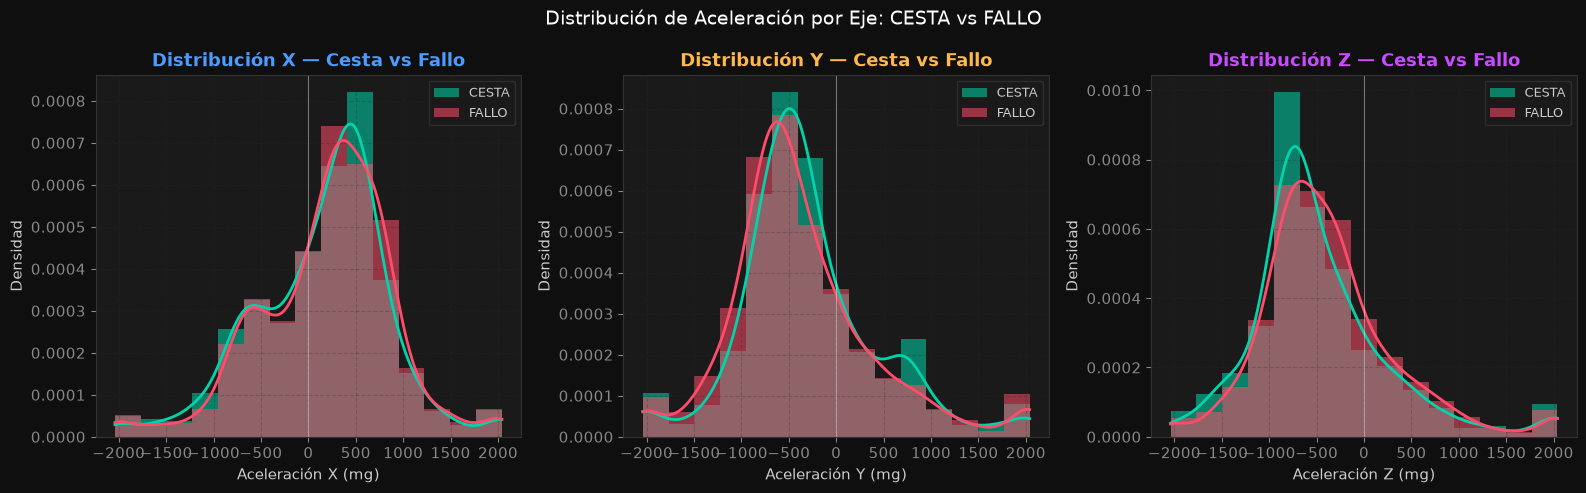

In [15]:
# ─── 10. Correlación entre ejes y resultado ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='#0F0F0F')

for ax, (eje, color) in zip(axes, [('x', X_COLOR), ('y', Y_COLOR), ('z', Z_COLOR)]):
    for grupo, c_grupo in [('CESTA', CESTA_COLOR), ('FALLO', FALLO_COLOR)]:
        sub = df[df['resultado'] == grupo]
        ax.hist(sub[eje], bins=15, color=c_grupo, alpha=0.55, label=grupo, density=True)

        # KDE manual con numpy
        vals = sub[eje].values
        if len(vals) > 2:
            kde_x = np.linspace(vals.min(), vals.max(), 200)
            kde_y = stats.gaussian_kde(vals)(kde_x)
            ax.plot(kde_x, kde_y, color=c_grupo, lw=2)

    ax.axvline(0, color='white', lw=0.8, alpha=0.4)
    ax.set_title(f'Distribución {eje.upper()} — Cesta vs Fallo', color=color)
    ax.set_xlabel(f'Aceleración {eje.upper()} (mg)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

fig.suptitle('Distribución de Aceleración por Eje: CESTA vs FALLO', fontsize=14, color='white')
plt.tight_layout()
plt.savefig('distribucion_ejes.png', dpi=150, bbox_inches='tight', facecolor='#0F0F0F')
plt.show()

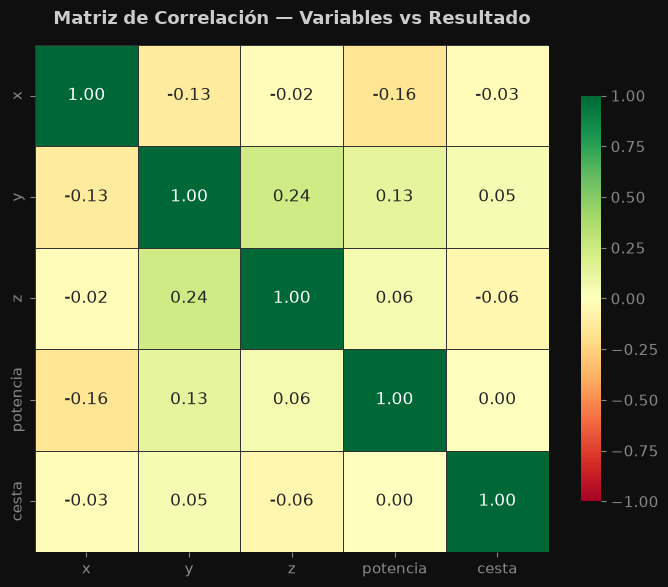


Correlación con cesta (ordenada):
y           0.05
potencia    0.00
x          -0.03
z          -0.06
Name: cesta, dtype: float64


In [16]:
# ─── 11. Heatmap de correlación ───────────────────────────────────────────────
corr = df[['x', 'y', 'z', 'potencia', 'cesta']].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 6), facecolor='#0F0F0F')
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True   # mostrar triángulo inferior

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='#333333',
            annot_kws={'size': 12},
            ax=ax, cbar_kws={'shrink': 0.8})

ax.set_title('Matriz de Correlación — Variables vs Resultado', pad=15)
plt.tight_layout()
plt.savefig('heatmap_correlacion.png', dpi=150, bbox_inches='tight', facecolor='#0F0F0F')
plt.show()

print('\nCorrelación con cesta (ordenada):')
print(corr['cesta'].drop('cesta').sort_values(ascending=False))

In [17]:
# ─── 12. Resumen final ────────────────────────────────────────────────────────
print('=' * 55)
print('           RESUMEN ANALÍTICO DE LA SESIÓN')
print('=' * 55)

print(f'\n🎯 Efectividad:    {metricas["cesta"].mean()*100:.1f}%  ({len(cestas_df)} cestas / {len(metricas)} tiros)')

print(f'\n⚡ Potencia:')
print(f'   Cestas  — prom: {cestas_df["pot_avg"].mean():.0f} mg  |  max: {cestas_df["pot_max"].mean():.0f} mg')
print(f'   Fallos  — prom: {fallos_df["pot_avg"].mean():.0f} mg  |  max: {fallos_df["pot_max"].mean():.0f} mg')
print(f'   Rango óptimo:  {cestas_df["pot_max"].min():.0f} – {cestas_df["pot_max"].max():.0f} mg')

print(f'\n🔄 Consistencia:')
print(f'   Cestas  — {cestas_df["consistencia"].mean():.3f}')
print(f'   Fallos  — {fallos_df["consistencia"].mean():.3f}')

print(f'\n⏱  Duración prom. del gesto: {metricas["duracion_ms"].mean():.0f} ms')

eje_corr = corr['cesta'].drop('cesta').abs().sort_values(ascending=False)
print(f'\n📐 Eje más correlacionado con cesta: {eje_corr.index[0].upper()} ({eje_corr.iloc[0]:.3f})')

tiro_raro = metricas.loc[metricas['pot_max'].idxmax()]
print(f'\n⚠️  Tiro con mayor potencia: #{int(tiro_raro["tiro"])} — {tiro_raro["pot_max"]:.0f} mg ({tiro_raro["resultado"]})')
print('=' * 55)
print(f'  ℹ️  Dataset pequeño ({len(TIROS)} tiros). Aumentar sesiones')
print('     para resultados estadísticamente robustos.')
print('=' * 55)

           RESUMEN ANALÍTICO DE LA SESIÓN

🎯 Efectividad:    33.8%  (139 cestas / 411 tiros)

⚡ Potencia:
   Cestas  — prom: 1316 mg  |  max: 2219 mg
   Fallos  — prom: 1314 mg  |  max: 2274 mg
   Rango óptimo:  1028 – 3273 mg

🔄 Consistencia:
   Cestas  — 0.629
   Fallos  — 0.615

⏱  Duración prom. del gesto: 4281 ms

📐 Eje más correlacionado con cesta: Z (0.060)

⚠️  Tiro con mayor potencia: #13 — 3413 mg (FALLO)
  ℹ️  Dataset pequeño (411 tiros). Aumentar sesiones
     para resultados estadísticamente robustos.
